# Methods

For this project, my approach was to make an image U-Net model which takes the .mat files and predicts the best image based on training with ground truth images. This project helped me re-learn how to write a more complex Pytorch model, exspecially in terms of dealing with data setup with the dataloaders. I struggled a lot with dealing with image sizing data structure requirements for different parts of PyTorch, but they were good lessons to learn! Unfortunately, due to some health issues I was experiencing during this project, I was not able to experiment as much as I wanted to in terms of tuning parameters and hyperparameters.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_163_DSA_8.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_118_DSA_2.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_164_DSA_2.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_146_DSA_3.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_149_DSA_3.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_164_DSA_4.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_150_DSA_4.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_166_DSA_3.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_120_DSA_3.mat
/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_133_

In [2]:
#Loading all dependencies

import scipy.io
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from tqdm.notebook import tqdm
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision.utils import save_image
import torchvision.utils as vutils

In [3]:
#Code using scipy to view 1 image (.mat files)

mat = scipy.io.loadmat('/kaggle/input/project-4-cosc-220-spring-2025/Training set - Input/Training set - Input/patient_008_DSA_3.mat')
mat['X']

array([[[686.29348165, 685.28288604, 687.71107475, ..., 686.40722557,
         686.05958233, 685.7119391 ],
        [686.34492993, 686.33878101, 685.68174938, ..., 670.08489555,
         669.11960641, 668.15431726],
        [684.59817863, 686.74505561, 686.80969596, ..., 664.32869598,
         663.76964988, 663.21060377],
        ...,
        [683.57928985, 687.03405819, 687.20788386, ..., 661.77677073,
         661.89984996, 662.02292919],
        [684.1515891 , 686.71836714, 687.57059025, ..., 661.22592158,
         660.55811155, 659.89030153],
        [683.87859404, 687.0680415 , 687.07560002, ..., 661.54972695,
         661.66265234, 661.77557772]],

       [[686.44976342, 685.97615693, 686.87543089, ..., 690.67652121,
         690.19861103, 689.72070086],
        [685.6688928 , 686.59769378, 686.6350141 , ..., 678.32379813,
         677.58318255, 676.84256697],
        [685.68185538, 686.87087447, 686.83529566, ..., 679.08902858,
         679.01807105, 678.94711351],
        ...,


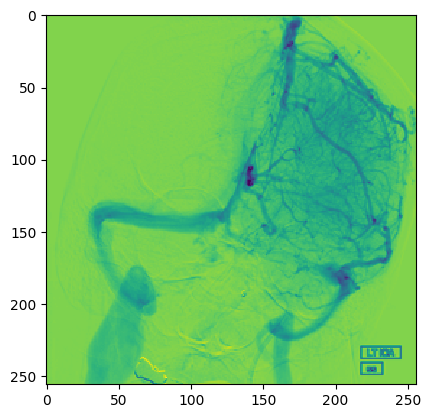

In [4]:
#Displaying the image

img = mat['X']
plt.imshow(img[:,:,15], interpolation='nearest')
plt.show()

#Future note: Do I want to convert all the images to .png? Or should I just train it as arrays...
#Maybe I can just display the image at the end to make sure the training set works okay?

In [5]:
#WHAT IS THE KEY
import scipy.io
mat_file_path = '/kaggle/input/project-4-cosc-220-spring-2025/Training set - Input/Training set - Input/patient_008_DSA_4.mat'
mat_data = scipy.io.loadmat(mat_file_path)

print("Keys in .mat file:", mat_data.keys())

Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'X'])


In [6]:
#WHAT IS THE KEY pt.2 (test set)

test_file_path = '/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input/patient_118_DSA_1.mat'
mat_contents = scipy.io.loadmat(test_file_path)
print(mat_contents.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X'])


In [7]:
#Data Pre-Processing
#I need to remind myself of how to do this

class BrainImageDataset(Dataset):

    def __init__(self, gt_dir, mat_dir, transform=None):
        self.gt_dir = gt_dir
        self.mat_dir = mat_dir
        self.transform = transform

        #Match mat files and GT image files
        self.mat_files = sorted([f for f in os.listdir(mat_dir) if f.endswith('.mat')])
        self.gt_images = sorted([f for f in os.listdir(gt_dir) if f.endswith('.png') or f.endswith('.jpg')])

    def __len__(self):
        return len(self.mat_files)

    def __getitem__(self, idx):
        #Load GT image
        gt_image_name = self.gt_images[idx]
        gt_image_path = os.path.join(self.gt_dir, gt_image_name)
        gt_image = Image.open(gt_image_path).convert('L') #'L' = 8-bit grayscale
    
        #Load candidate images from .mat file
        mat_file_path = os.path.join(self.mat_dir, self.mat_files[idx])
        mat_data = scipy.io.loadmat(mat_file_path)
        candidate_images = mat_data['X']  #shape: (H, W, 20)
    
        #Rearrange shape
        candidate_images = np.transpose(candidate_images, (2, 0, 1))  #now (20, H, W)
    
        #Normalize and convert to PIL
        if self.transform:
            gt_image = self.transform(gt_image)
    
            candidate_images = torch.stack([
                self.transform(Image.fromarray(img.astype(np.float32))) for img in candidate_images
            ])
    
        return candidate_images, gt_image

data_transforms = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])
        

#dataset and dataloader
mat_dir = '/kaggle/input/project-4-cosc-220-spring-2025/Training set - Input/Training set - Input'
gt_dir = '/kaggle/input/project-4-cosc-220-spring-2025/Training set- GT/Training set- GT'

dataset = BrainImageDataset(mat_dir=mat_dir, gt_dir=gt_dir, transform=data_transforms)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

#testing to see if the dataloader works right
for candidate_images, gt_image in dataloader:
    print(f"Candidate Images Shape: {candidate_images.shape}, GT Image Shape: {gt_image.shape}")
    break

Candidate Images Shape: torch.Size([2, 20, 1, 1024, 1024]), GT Image Shape: torch.Size([2, 1, 1024, 1024])


In [8]:
#test data setup
#I ended up having to make a different class for the test dataset due to no GT files lol

class BrainTestDataset(Dataset):
    def __init__(self, mat_filenames, mat_dir, transform=None):
        self.mat_filenames = mat_filenames
        self.mat_dir = mat_dir
        self.transform = transform

    def __len__(self):
        return len(self.mat_filenames)

    def __getitem__(self, idx):
        mat_name = self.mat_filenames[idx]
        mat_path = os.path.join(self.mat_dir, mat_name)

        mat_data = scipy.io.loadmat(mat_path)['X'] 
        mat_tensor = torch.tensor(mat_data).float().unsqueeze(1) 

        if self.transform:
            mat_tensor = self.transform(mat_tensor)

        return mat_tensor, mat_name 

test_mat_dir = '/kaggle/input/project-4-cosc-220-spring-2025/Test set - Input/Test set - Input'
test_mat_files = sorted([f for f in os.listdir(test_mat_dir) if f.endswith(".mat")])

test_dataset = BrainTestDataset(test_mat_files, test_mat_dir)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


In [9]:
#Model Section

class BrainPerfusionUNet(nn.Module):
    def __init__(self, in_channels=20, out_channels=3):
        super(BrainPerfusionUNet, self).__init__()

        #This learns edges and textures from the image
        #reduces the resolution to leanr more about the image (downsampling)
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)  #pixels are now 512x512

        #same as above but downsamples even more
        self.encoder2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)  #pixels are now 256x256

        #the deepest layer of the nn! 
        #super compresseed features (most abstract representation)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU()
        )

        #unsampling and concatenating 
        #decodes the encoder but blends and refines the features the encoder found
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)  #pixel increase back to 512x512
        self.decoder2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        #same as the first decoder but decoding more
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)  #pixel increase back to 1024x1024
        self.decoder1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        #Gives the final output image!
        self.final_conv = nn.Conv2d(64, 1, 1) 
    
    def forward(self, x):
        #Encoder (downsampling)
        #reduce spatial resolution and increase image abstraction so the model can learn defining features from the image
        e1 = self.encoder1(x)
        p1 = self.pool1(e1)
        e2 = self.encoder2(p1)
        p2 = self.pool2(e2)
        
        #Bottleneck
        #the deepest nn layer that helps with prediction
        b = self.bottleneck(p2)
        
        #Decoder
        #unsampling where it takes the data back to the original convolution and reoslution and concatenates features from the encoder
        up2 = self.upconv2(b)
        cat2 = torch.cat([up2, e2], dim=1)
        d2 = self.decoder2(cat2)
        
        up1 = self.upconv1(d2)
        cat1 = torch.cat([up1, e1], dim=1)
        d1 = self.decoder1(cat1)
        
        #Output
        #returns the final prediction image!
        out = self.final_conv(d1)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = BrainPerfusionUNet(in_channels=20, out_channels=3).to(device)

criterion = nn.MSELoss()  # or nn.L1Loss() if you want pixel-wise MAE
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Dummy input test
x = torch.randn(2, 20, 1024, 1024).to(device)
y = model(x)
print(y.shape)  # Should be [2, 3, 1024, 1024]


Using device: cuda
torch.Size([2, 1, 1024, 1024])


In [10]:
#Training loop!

num_epochs = 7 

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (candidate_images, gt_image) in enumerate(dataloader):
        candidate_images = candidate_images.to(device)
        gt_image = gt_image.to(device) 

        #Merge 20 grayscale channels to 20-channel input (remove singleton dim)
        candidate_images = candidate_images.squeeze(2)  # [B, 20, 1024, 1024]

        #Output optimizer and loss
        outputs = model(candidate_images)
        loss = criterion(outputs, gt_image)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        #saving the image 
        vutils.save_image(outputs, f"predicted_epoch{epoch}_batch{batch_idx}.png", normalize=True)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/7], Loss: 41.2589
Epoch [2/7], Loss: 2.9262
Epoch [3/7], Loss: 0.8168
Epoch [4/7], Loss: 0.3145
Epoch [5/7], Loss: 0.2549
Epoch [6/7], Loss: 0.1461
Epoch [7/7], Loss: 0.1354


In [11]:
#Test set time 
#I am also integrating the output saving into here as well

model.eval()
output_dir = '/kaggle/working/predicted_images/'
os.makedirs(output_dir, exist_ok=True)

with torch.no_grad():
    for inputs, filename in test_loader:
        inputs = inputs.to(device)  # [1, 20, 1, 1024, 1024]
        inputs = inputs.squeeze(2)  # remove singleton channel: [1, 20, 1024, 1024]
        inputs = inputs.permute(0, 3, 1, 2)  # from [1, 256, 256, 20] -> [1, 20, 256, 256]
        output = model(inputs)  # [1, 1, 1024, 1024]
        output = torch.clamp(output, 0.0, 1.0)  # make sure it's in image range

        # Save as grayscale PNG
        pred_path = os.path.join(output_dir, f'{filename[0]}_predicted.png')
        print(f'Saving prediction for {filename[0]}')
        vutils.save_image(output, pred_path, normalize=True)

print('IT WORKED RIGHT WOOOOOOOOO')

#Debug this tomorrow :)

Saving prediction for patient_118_DSA_1.mat
Saving prediction for patient_118_DSA_2.mat
Saving prediction for patient_118_DSA_3.mat
Saving prediction for patient_118_DSA_4.mat
Saving prediction for patient_120_DSA_3.mat
Saving prediction for patient_120_DSA_4.mat
Saving prediction for patient_133_DSA_1.mat
Saving prediction for patient_133_DSA_2.mat
Saving prediction for patient_144_DSA_1.mat
Saving prediction for patient_144_DSA_2.mat
Saving prediction for patient_144_DSA_3.mat
Saving prediction for patient_144_DSA_4.mat
Saving prediction for patient_146_DSA_2.mat
Saving prediction for patient_146_DSA_3.mat
Saving prediction for patient_146_DSA_4.mat
Saving prediction for patient_147_DSA_1.mat
Saving prediction for patient_147_DSA_3.mat
Saving prediction for patient_147_DSA_4.mat
Saving prediction for patient_149_DSA_1.mat
Saving prediction for patient_149_DSA_2.mat
Saving prediction for patient_149_DSA_3.mat
Saving prediction for patient_149_DSA_4.mat
Saving prediction for patient_15

# Literature Review

- Try Kernel Spectral Regression or KSR
- Averaging the 20 images?
- auto encoder?
- Remove too intense images? Image intensity threshold?

# To Do List

The dataloader and dataset setup is complete! Now time to build the model. 

1. Debug the test set and make a successful working output to .png 

2. When your baseline is complete, start experimenting!